In [19]:
import pandas as pd
import numpy as np

In [20]:
ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    encoding="latin1",
    names=["movie_id", "title", "genres"]
)

users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

In [21]:
df = ratings.merge(users, on="user_id")
df = df.merge(movies, on="movie_id")

print(df.shape)
df.head()

(1000209, 10)


,user_id,movie_id,rating,timestamp,gender,age,occupation,zip_code,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [22]:
df["year"] = df["title"].str.extract(r"\((\d{4})\)$")

df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)
df["gender"] = df["gender"].map({
    "M": 0,
    "F": 1
})
age_dummies = pd.get_dummies(
    df["age"],
    prefix="age",
    drop_first=True
)

df = pd.concat(
    [df, age_dummies],
    axis=1
)

occupation_dummies = pd.get_dummies(
    df["occupation"],
    prefix="occ",
    drop_first=True
)

df = pd.concat(
    [df, occupation_dummies],
    axis=1
)
genres = set()

for g in df["genres"]:
    genres.update(g.split("|"))

genres = sorted(genres)

print(genres)

['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [23]:
for genre in genres:

    df[genre] = (
        df["genres"]
        .str.contains(genre, regex=False)
        .astype(int)
    )

In [24]:
# User genre preference features

for genre in genres:

    genre_avg = (
        df[df[genre] == 1]
        .groupby("user_id")["rating"]
        .mean()
    )

    df[f"user_pref_{genre}"] = (
        df["user_id"]
        .map(genre_avg)
    )

    df[f"user_pref_{genre}"] = (
        df[f"user_pref_{genre}"]
        .fillna(df["rating"].mean())
    )

In [25]:
user_avg = (
    df.groupby("user_id")["rating"]
      .mean()
)

df["user_avg_rating"] = (
    df["user_id"]
      .map(user_avg)
)
user_count = (
    df.groupby("user_id")["rating"]
      .count()
)

df["user_rating_count"] = (
    df["user_id"]
      .map(user_count)
)

In [26]:
movie_avg = (
    df.groupby("movie_id")["rating"]
      .mean()
)

df["movie_avg_rating"] = (
    df["movie_id"]
      .map(movie_avg)
)
movie_count = (
    df.groupby("movie_id")["rating"]
      .count()
)

df["movie_rating_count"] = (
    df["movie_id"]
      .map(movie_count)
)
movie_std = (
    df.groupby("movie_id")["rating"]
      .std()
)

df["movie_rating_std"] = (
    df["movie_id"]
      .map(movie_std)
)

df["movie_rating_std"] = (
    df["movie_rating_std"]
      .fillna(0)
)

df["user_movie_interaction"] = (
    df["user_avg_rating"]
    *
    df["movie_avg_rating"]
)

In [27]:
df["datetime"] = pd.to_datetime(
    df["timestamp"],
    unit="s"
)

df["rating_year"] = df["datetime"].dt.year

df["rating_month"] = df["datetime"].dt.month

df["movie_age"] = (
    df["rating_year"] - df["year"]
)

In [28]:
feature_columns = [
    "user_id",
    "movie_id",
    "gender",
    "year",
    "user_avg_rating",
    "user_rating_count",
    "movie_avg_rating",
    "movie_rating_count"
]
feature_columns.append("movie_rating_std")
feature_columns += list(age_dummies.columns)
feature_columns += list(occupation_dummies.columns)
feature_columns += genres
feature_columns.extend([
    "rating_year",
    "rating_month",
    "movie_age"
])
feature_columns.append(
    "user_movie_interaction"
)
pref_cols = [
    col
    for col in df.columns
    if col.startswith("user_pref_")
]

feature_columns += pref_cols

In [29]:
X = df[feature_columns]

y = df["rating"]

print(X.shape)
print(y.shape)

X.head()

(1000209, 75)
(1000209,)


,user_id,movie_id,gender,year,user_avg_rating,user_rating_count,movie_avg_rating,movie_rating_count,movie_rating_std,age_18,...,user_pref_Fantasy,user_pref_Film-Noir,user_pref_Horror,user_pref_Musical,user_pref_Mystery,user_pref_Romance,user_pref_Sci-Fi,user_pref_Thriller,user_pref_War,user_pref_Western
0,1,1193,1,1975,4.188679,53,4.390725,1725,0.789524,False,...,4.0,3.581564,3.581564,4.285714,3.581564,3.666667,4.333333,3.666667,5.0,3.581564
1,1,661,1,1996,4.188679,53,3.464762,525,1.023202,False,...,4.0,3.581564,3.581564,4.285714,3.581564,3.666667,4.333333,3.666667,5.0,3.581564
2,1,914,1,1964,4.188679,53,4.154088,636,0.873854,False,...,4.0,3.581564,3.581564,4.285714,3.581564,3.666667,4.333333,3.666667,5.0,3.581564
3,1,3408,1,2000,4.188679,53,3.863878,1315,0.895887,False,...,4.0,3.581564,3.581564,4.285714,3.581564,3.666667,4.333333,3.666667,5.0,3.581564
4,1,2355,1,1998,4.188679,53,3.854375,1703,0.879284,False,...,4.0,3.581564,3.581564,4.285714,3.581564,3.666667,4.333333,3.666667,5.0,3.581564


In [22]:
processed_df = df[
    feature_columns + ["rating"]
]

processed_df.to_csv(
    "movielens_processed.csv",
    index=False
)

print("Saved.")

Saved.


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_linear = X_train.drop(
    columns=["user_id", "movie_id"]
)

X_test_linear = X_test.drop(
    columns=["user_id", "movie_id"]
)

print(X_train.shape)
print(X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

scaler_linear = StandardScaler()

X_train_linear_scaled = scaler_linear.fit_transform(
    X_train_linear
)

X_test_linear_scaled = scaler_linear.transform(
    X_test_linear
)



(800167, 75)
(200042, 75)


In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_linear_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_linear_scaled
)

lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

print(lr_results)

{'Model': 'Linear Regression', 'MAE': 0.724155810247813, 'MSE': 0.8342833195581114, 'RMSE': np.float64(0.9133911098527899), 'R2': 0.3345922597502351}


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

print(rf_results)

{'Model': 'Random Forest', 'MAE': 0.709460545469575, 'MSE': 0.8022677265050622, 'RMSE': np.float64(0.8956939915535116), 'R2': 0.3601272583853141}


In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

print(xgb_results)

{'Model': 'XGBoost', 'MAE': 0.6624814867973328, 'MSE': 0.7094825506210327, 'RMSE': np.float64(0.8423078716366319), 'R2': 0.43413084745407104}


In [35]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,MSE,RMSE,R2
2,XGBoost,0.662481,0.709483,0.842308,0.434131
1,Random Forest,0.709461,0.802268,0.895694,0.360127
0,Linear Regression,0.724156,0.834283,0.913391,0.334592


In [36]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                   Feature  Importance
56  user_movie_interaction    0.239635
41             Documentary    0.029132
44               Film-Noir    0.022418
37               Animation    0.021516
52                 Western    0.020711
45                  Horror    0.019072
46                 Musical    0.016279
35                  Action    0.016102
51                     War    0.015861
43                 Fantasy    0.015488
38              Children's    0.015322
57        user_pref_Action    0.014747
4          user_avg_rating    0.013569
47                 Mystery    0.013467
64         user_pref_Drama    0.012726
24                  occ_10    0.012607
66     user_pref_Film-Noir    0.012528
40                   Crime    0.012454
49                  Sci-Fi    0.012306
48                 Romance    0.012260


In [47]:
def recommend_movies(
    gender,
    age_group,
    occupation,
    genre1,
    genre2,
    genre3,
    release_period,
    top_n=5
):

    candidate_movies = df.copy()

    # =====================================================
    # GENRE FILTERING
    # =====================================================

    selected_genres = [
        g for g in [genre1, genre2, genre3]
        if g != "None"
    ]

    if len(selected_genres) > 0:

        genre_filter = pd.Series(
            False,
            index=candidate_movies.index
        )

        for g in selected_genres:

            genre_filter = (
                genre_filter |
                (candidate_movies[g] == 1)
            )

        candidate_movies = candidate_movies[
            genre_filter
        ]

    # =====================================================
    # RELEASE PERIOD FILTER
    # =====================================================

    if release_period == "Classic":

        candidate_movies = candidate_movies[
            candidate_movies["year"] < 1980
        ]

    elif release_period == "1980-1999":

        candidate_movies = candidate_movies[
            (candidate_movies["year"] >= 1980) &
            (candidate_movies["year"] <= 1999)
        ]

    elif release_period == "2000+":

        candidate_movies = candidate_movies[
            candidate_movies["year"] >= 2000
        ]

    # =====================================================
    # NO MOVIES FOUND
    # =====================================================

    if len(candidate_movies) == 0:

        return pd.DataFrame({
            "Message": [
                "No movies found matching criteria."
            ]
        })

    # =====================================================
    # REMOVE DUPLICATES
    # =====================================================

    candidate_movies = (
        candidate_movies
        .sort_values(
            "movie_rating_count",
            ascending=False
        )
        .drop_duplicates("movie_id")
        .copy()
    )

    # =====================================================
    # FEATURE MATRIX
    # =====================================================

    X_rec = pd.DataFrame(
        0,
        index=candidate_movies.index,
        columns=feature_columns
    )

    # =====================================================
    # COPY EXISTING MOVIE FEATURES
    # =====================================================

    common_features = [
        col for col in feature_columns
        if col in candidate_movies.columns
    ]

    X_rec[common_features] = (
        candidate_movies[common_features]
    )

    # =====================================================
    # USER FEATURES
    # =====================================================

    X_rec["gender"] = gender

    age_col = f"age_{age_group}"

    if age_col in X_rec.columns:
        X_rec[age_col] = 1

    occ_col = f"occ_{occupation}"

    if occ_col in X_rec.columns:
        X_rec[occ_col] = 1

    # =====================================================
    # DEFAULT USER STATISTICS
    # =====================================================

    global_user_avg = df["rating"].mean()

    global_user_count = (
        df["user_rating_count"]
        .median()
    )

    if "user_avg_rating" in X_rec.columns:
        X_rec["user_avg_rating"] = (
            global_user_avg
        )

    if "user_rating_count" in X_rec.columns:
        X_rec["user_rating_count"] = (
            global_user_count
        )

    # =====================================================
    # USER PREFERENCE FEATURES
    # =====================================================

    pref_cols = [
        c for c in X_rec.columns
        if c.startswith("user_pref_")
    ]

    for col in pref_cols:
        X_rec[col] = global_user_avg

    for genre in selected_genres:

        pref_col = f"user_pref_{genre}"

        if pref_col in X_rec.columns:
            X_rec[pref_col] = 5.0

    # =====================================================
    # USER-MOVIE INTERACTION
    # =====================================================

    if (
        "user_movie_interaction"
        in X_rec.columns
    ):

        X_rec["user_movie_interaction"] = (
            X_rec["user_avg_rating"]
            *
            X_rec["movie_avg_rating"]
        )

    # =====================================================
    # MODEL FEATURES NOT PROVIDED BY USER
    # =====================================================

    if "user_id" in X_rec.columns:
        X_rec["user_id"] = 0

    if "movie_id" in X_rec.columns:
        X_rec["movie_id"] = (
            candidate_movies["movie_id"]
        )

    # =====================================================
    # PREDICT
    # =====================================================

    candidate_movies["predicted_rating"] = (
        xgb.predict(X_rec)
    )

    # =====================================================
    # TOP RECOMMENDATIONS
    # =====================================================

    recommendations = (
        candidate_movies[
            [
                "title",
                "genres",
                "year",
                "predicted_rating"
            ]
        ]
        .sort_values(
            "predicted_rating",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations

In [48]:
# ==========================================================
# WIDGETS
# ==========================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================================
# OCCUPATION DICTIONARY
# ==========================================================

occupation_dict = {
    0: "Other",
    1: "Academic/Educator",
    2: "Artist",
    3: "Clerical/Admin",
    4: "College Student",
    5: "Customer Service",
    6: "Doctor/Health Care",
    7: "Executive/Managerial",
    8: "Farmer",
    9: "Homemaker",
    10: "K-12 Student",
    11: "Lawyer",
    12: "Programmer",
    13: "Retired",
    14: "Sales/Marketing",
    15: "Scientist",
    16: "Self-employed",
    17: "Engineer",
    18: "Tradesman",
    19: "Unemployed",
    20: "Writer"
}

# ==========================================================
# INPUT WIDGETS
# ==========================================================

gender_widget = widgets.Dropdown(
    options=["Male", "Female"],
    value="Male",
    description="Gender:"
)

age_widget = widgets.Dropdown(
    options=[
        ("Under 18", 1),
        ("18-24", 18),
        ("25-34", 25),
        ("35-44", 35),
        ("45-49", 45),
        ("50-55", 50),
        ("56+", 56)
    ],
    value=25,
    description="Age:"
)

occupation_widget = widgets.Dropdown(
    options=[(v, k) for k, v in occupation_dict.items()],
    value=12,
    description="Occupation:"
)

genre_options = ["None"] + sorted(genres)

genre1_widget = widgets.Dropdown(
    options=genre_options,
    value="Sci-Fi",
    description="Genre 1:"
)

genre2_widget = widgets.Dropdown(
    options=genre_options,
    value="Action",
    description="Genre 2:"
)

genre3_widget = widgets.Dropdown(
    options=genre_options,
    value="None",
    description="Genre 3:"
)

release_widget = widgets.Dropdown(
    options=[
        "Any",
        "Classic",
        "1980-1999",
        "2000+"
    ],
    value="Any",
    description="Release:"
)

topn_widget = widgets.IntSlider(
    value=5,
    min=3,
    max=20,
    step=1,
    description="Top N:"
)

recommend_button = widgets.Button(
    description="Recommend Movies",
    button_style="success",
    icon="film"
)

output = widgets.Output()

# ==========================================================
# BUTTON CALLBACK
# ==========================================================

def on_button_clicked(b):

    with output:

        clear_output()

        recommendations = recommend_movies(
            gender=0 if gender_widget.value == "Male" else 1,
            age_group=age_widget.value,
            occupation=occupation_widget.value,
            genre1=genre1_widget.value,
            genre2=genre2_widget.value,
            genre3=genre3_widget.value,
            release_period=release_widget.value,
            top_n=topn_widget.value
        )

        print("\nRecommended Movies:\n")

        display(
            recommendations.reset_index(drop=True)
        )

recommend_button.on_click(
    on_button_clicked
)

# ==========================================================
# DISPLAY UI
# ==========================================================

display(
    widgets.VBox([
        widgets.HTML(
            "<h2> Movie Recommendation System</h2>"
        ),

        gender_widget,
        age_widget,
        occupation_widget,

        widgets.HTML("<b>Preferred Genres</b>"),

        genre1_widget,
        genre2_widget,
        genre3_widget,

        release_widget,

        topn_widget,

        recommend_button,

        output
    ])
)

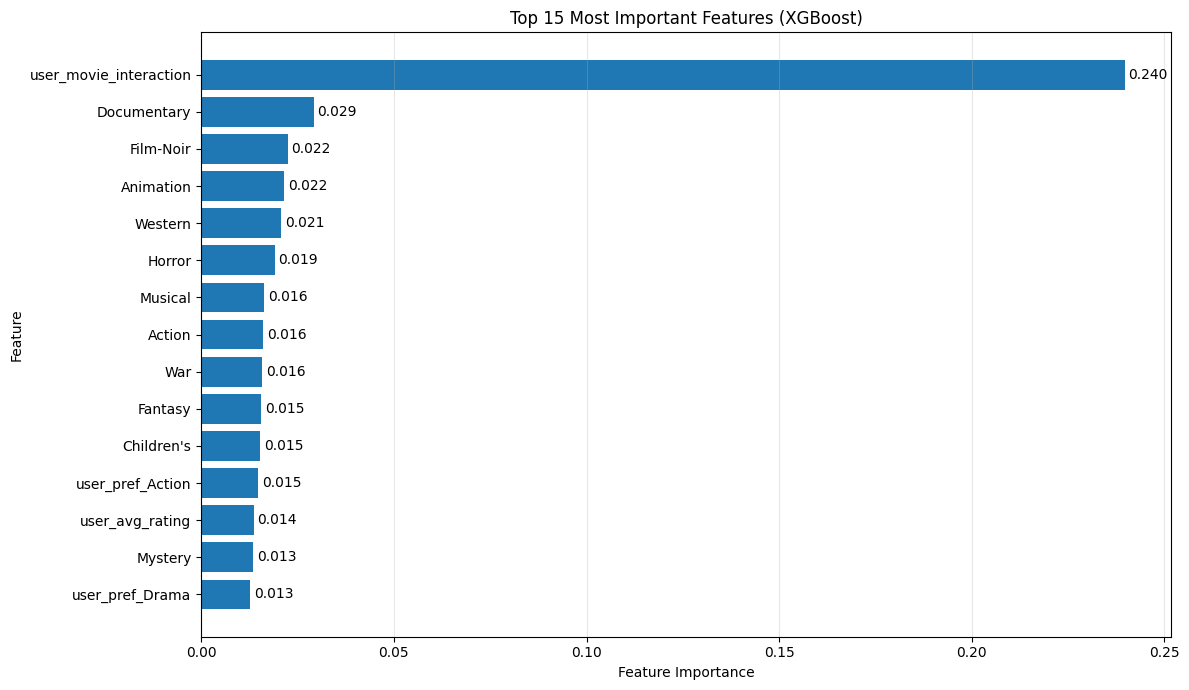

In [62]:
import matplotlib.pyplot as plt

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
)

top_features = importance_df.head(15)

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 15 Most Important Features (XGBoost)")
ax.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()